In [135]:
begin
    using Pkg
    dev_folder = joinpath(@__DIR__, "../Examples")
    Pkg.activate(dev_folder)
end
Threads.nthreads()

  Activating project at `~/Realizibility_index/BindingAndCatalysis.jl/Examples`


24

In [136]:
using Polyhedra
using GLMakie # for plotting, we use Makie backend, could also be GLMakie or WGLMakie...
using Revise
using BindingAndCatalysis # import the package

In [7]:
N = [1 0 1 0 -1 0 
     0 1 0 1 0 -1
     0 0 0 0 1 -1]
N2 = [1 0 1 0 -1 0 
     0 1 0 1 0 -1]

2×6 Matrix{Int64}:
 1  0  1  0  -1   0
 0  1  0  1   0  -1

In [6]:
L = BindingAndCatalysis.L_from_N(N)

3×6 Matrix{Int64}:
 1  0  0   1  1  1
 0  1  0  -1  0  0
 0  0  1   1  1  1

In [8]:
L2 = BindingAndCatalysis.L_from_N(N2)

4×6 Matrix{Int64}:
 1  0  0  0  1  0
 0  1  0  0  0  1
 0  0  1  0  1  0
 0  0  0  1  0  1

In [11]:
L3 = L2[1:3,:]
L3[3,:] += L2[4,:]

6-element Vector{Int64}:
 0
 0
 1
 1
 1
 1

In [16]:
perm_org = find_all_vertices(L2)

16-element Vector{Vector{Int8}}:
 [1, 2, 3, 4]
 [1, 2, 3, 6]
 [1, 2, 5, 4]
 [1, 2, 5, 6]
 [1, 6, 3, 4]
 [1, 6, 3, 6]
 [1, 6, 5, 4]
 [1, 6, 5, 6]
 [5, 2, 3, 4]
 [5, 2, 3, 6]
 [5, 2, 5, 4]
 [5, 2, 5, 6]
 [5, 6, 3, 4]
 [5, 6, 3, 6]
 [5, 6, 5, 4]
 [5, 6, 5, 6]

In [23]:
perm_cat = find_all_vertices(L3)

16-element Vector{Vector{Int8}}:
 [1, 2, 3]
 [1, 6, 3]
 [5, 2, 3]
 [5, 6, 3]
 [1, 2, 4]
 [1, 6, 4]
 [5, 2, 4]
 [5, 6, 4]
 [1, 2, 5]
 [1, 6, 5]
 [5, 2, 5]
 [5, 6, 5]
 [1, 2, 6]
 [1, 6, 6]
 [5, 2, 6]
 [5, 6, 6]

In [24]:
L3

3×6 Matrix{Int64}:
 1  0  0  0  1  0
 0  1  0  0  0  1
 0  0  1  1  1  1

In [21]:
L_cmb = vcat(L3[[3],:], L2)

5×6 Matrix{Int64}:
 0  0  1  1  1  1
 1  0  0  0  1  0
 0  1  0  0  0  1
 0  0  1  0  1  0
 0  0  0  1  0  1

In [22]:
perm_cmb = find_all_vertices(L_cmb)

32-element Vector{Vector{Int8}}:
 [3, 1, 2, 3, 4]
 [3, 1, 2, 3, 6]
 [3, 1, 6, 3, 4]
 [3, 1, 6, 3, 6]
 [3, 5, 2, 3, 4]
 [3, 5, 2, 3, 6]
 [3, 5, 6, 3, 4]
 [3, 5, 6, 3, 6]
 [4, 1, 2, 3, 4]
 [4, 1, 2, 5, 4]
 [4, 1, 6, 3, 4]
 [4, 1, 6, 5, 4]
 [4, 5, 2, 3, 4]
 ⋮
 [5, 5, 2, 5, 4]
 [5, 5, 2, 5, 6]
 [5, 5, 6, 5, 4]
 [5, 5, 6, 5, 6]
 [6, 1, 2, 3, 6]
 [6, 1, 2, 5, 6]
 [6, 1, 6, 3, 6]
 [6, 1, 6, 5, 6]
 [6, 5, 2, 3, 6]
 [6, 5, 2, 5, 6]
 [6, 5, 6, 3, 6]
 [6, 5, 6, 5, 6]

In [25]:
pairs = let 
    f(p) = p[[2,3,1]] => p[[2,3,4,5]]
    f.(perm_cmb)
end

32-element Vector{Pair{Vector{Int8}, Vector{Int8}}}:
 [1, 2, 3] => [1, 2, 3, 4]
 [1, 2, 3] => [1, 2, 3, 6]
 [1, 6, 3] => [1, 6, 3, 4]
 [1, 6, 3] => [1, 6, 3, 6]
 [5, 2, 3] => [5, 2, 3, 4]
 [5, 2, 3] => [5, 2, 3, 6]
 [5, 6, 3] => [5, 6, 3, 4]
 [5, 6, 3] => [5, 6, 3, 6]
 [1, 2, 4] => [1, 2, 3, 4]
 [1, 2, 4] => [1, 2, 5, 4]
 [1, 6, 4] => [1, 6, 3, 4]
 [1, 6, 4] => [1, 6, 5, 4]
 [5, 2, 4] => [5, 2, 3, 4]
           ⋮
 [5, 2, 5] => [5, 2, 5, 4]
 [5, 2, 5] => [5, 2, 5, 6]
 [5, 6, 5] => [5, 6, 5, 4]
 [5, 6, 5] => [5, 6, 5, 6]
 [1, 2, 6] => [1, 2, 3, 6]
 [1, 2, 6] => [1, 2, 5, 6]
 [1, 6, 6] => [1, 6, 3, 6]
 [1, 6, 6] => [1, 6, 5, 6]
 [5, 2, 6] => [5, 2, 3, 6]
 [5, 2, 6] => [5, 2, 5, 6]
 [5, 6, 6] => [5, 6, 3, 6]
 [5, 6, 6] => [5, 6, 5, 6]

In [32]:
filter(pairs) do p p.first[3] == 3 end

8-element Vector{Pair{Vector{Int8}, Vector{Int8}}}:
 [1, 2, 3] => [1, 2, 3, 4]
 [1, 2, 3] => [1, 2, 3, 6]
 [1, 6, 3] => [1, 6, 3, 4]
 [1, 6, 3] => [1, 6, 3, 6]
 [5, 2, 3] => [5, 2, 3, 4]
 [5, 2, 3] => [5, 2, 3, 6]
 [5, 6, 3] => [5, 6, 3, 4]
 [5, 6, 3] => [5, 6, 3, 6]

In [137]:
model1 = let
        N =     [1      1    -1    0
                1      0      1    -1]
        model = Bnc(N=N)
end

model2 = let
        N = model1.N
        L = Int.(model1.L .> 0)
        model = Bnc(N=N,L=L)
end



----------Binding Network Summary:-------------
Number of species (n): 4
Number of conserved quantities (d): 2
Number of reactions (r): 2
L matrix: [1 0 1 1; 0 1 1 1]
N matrix: [1 1 -1 0; 1 0 1 -1]
Direction of binding reactions: forward
Catalysis involved: No
Regimes constructed: No
-----------------------------------------------

[ Info: ---------------------Start finding all vertices--------------------
[ Info: Finished, with 7 vertices found and 7 asymptotic vertices.
[ Info: -------------Start calculating nullity for each vertex, it also takes a while.------------
[ Info: 1.Building Nρ_inv cache in parallel...
[ Info: 2.Calculating nullity for each vertex in parallel...
[ Info: Start calculating vertices neighbor graph, It may takes a while.
[ Info: Calculating vertices neighbor graph with qK change dir
[ Info: Number of polyhedra to calc volume: 5
[ Info: All regimes converged after 2400000 samples.


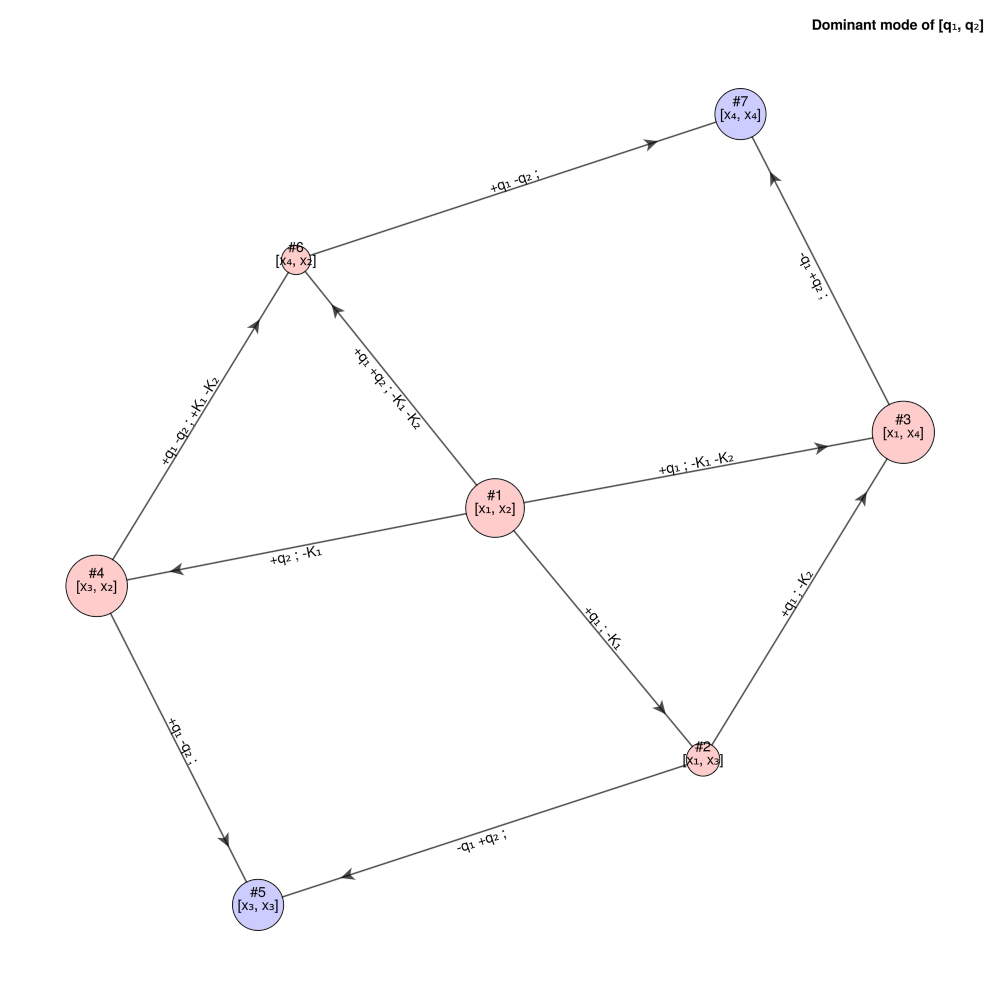

In [41]:
f,ax,p = draw_graph(model2)
f

In [138]:
p1 = SISOPaths(model1, 1)

[ Info: ---------------------Start finding all vertices--------------------
[ Info: Finished, with 8 vertices found and 7 asymptotic vertices.
[ Info: -------------Start calculating nullity for each vertex, it also takes a while.------------
[ Info: 1.Building Nρ_inv cache in parallel...
[ Info: 2.Calculating nullity for each vertex in parallel...
[ Info: Start calculating vertices neighbor graph, It may takes a while.
[ Info: Calculating vertices neighbor graph with qK change dir
[ Info: sources: [4, 1]
[ Info: sinks: [3]
[ Info: Start enumerating paths from sources to sinks. This may take a while if there are many paths.
[ Info: Total vertices to process in topological order: 8
[ Info: Finished enumerating paths. Now collecting paths from sources. Total sources: 2


SISOPaths{Int8}(Bnc{Int8}([1 1 -1 0; 1 0 1 -1], [1 0 1 2; 0 1 1 1], 2, 4, 2, Symbolics.Num[x₁, x₂, x₃, x₄], Symbolics.Num[q₁, q₂], Symbolics.Num[K₁, K₂], nothing, Vector{Int8}[[1, 2], [1, 3], [1, 4], [3, 2], [3, 3], [4, 2], [4, 3], [4, 4]], Dict{Vector{Int8}, Int64}([4, 2] => 6, [1, 3] => 2, [3, 3] => 5, [1, 4] => 3, [1, 2] => 1, [4, 3] => 7, [3, 2] => 4, [4, 4] => 8), Bool[1, 1, 1, 1, 1, 1, 0, 1], Int8[0, 0, 0, 0, 1, 0, 0, 1], BindingAndCatalysis.VertexGraph{Int8}(Bnc{Int8}(#= circular reference @-2 =#), Graphs.SimpleGraphs.SimpleGraph{Int64}(14, [[2, 3, 4, 6], [1, 3, 5, 7], [1, 2, 8], [1, 5, 6], [2, 4, 7], [1, 4, 7, 8], [2, 5, 6, 8], [3, 6, 7]]), Vector{BindingAndCatalysis.VertexEdge{Int8}}[[BindingAndCatalysis.VertexEdge{Int8}(2, 2, sparsevec(Int8[2, 3], Int8[-1, 1], 4), -0.0, sparsevec(Int8[1, 3], [1.0, -1.0], 4), 0.0), BindingAndCatalysis.VertexEdge{Int8}(3, 2, sparsevec(Int8[2, 4], Int8[-1, 1], 4), -0.0, sparsevec(Int8[1, 3, 4], [2.0, -1.0, -1.0], 4), 0.0), BindingAndCatalysis.Ve

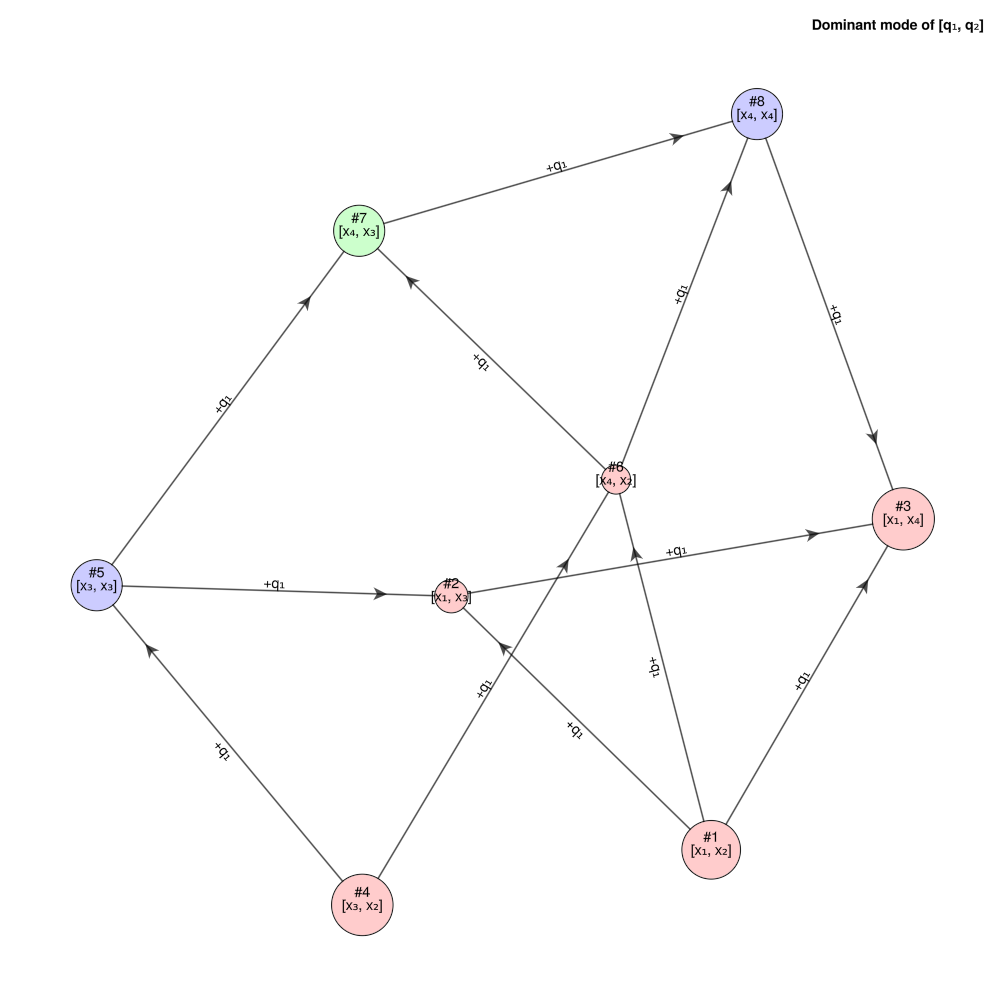

In [47]:
f,ax = draw_graph(p1); f

[ Info: ---------------------Start finding all vertices--------------------
[ Info: Finished, with 8 vertices found and 7 asymptotic vertices.
[ Info: -------------Start calculating nullity for each vertex, it also takes a while.------------
[ Info: 1.Building Nρ_inv cache in parallel...
[ Info: 2.Calculating nullity for each vertex in parallel...
[ Info: Start calculating vertices neighbor graph, It may takes a while.
[ Info: Calculating vertices neighbor graph with qK change dir
[ Info: Number of polyhedra to calc volume: 5
[ Info: All regimes converged after 2400000 samples.


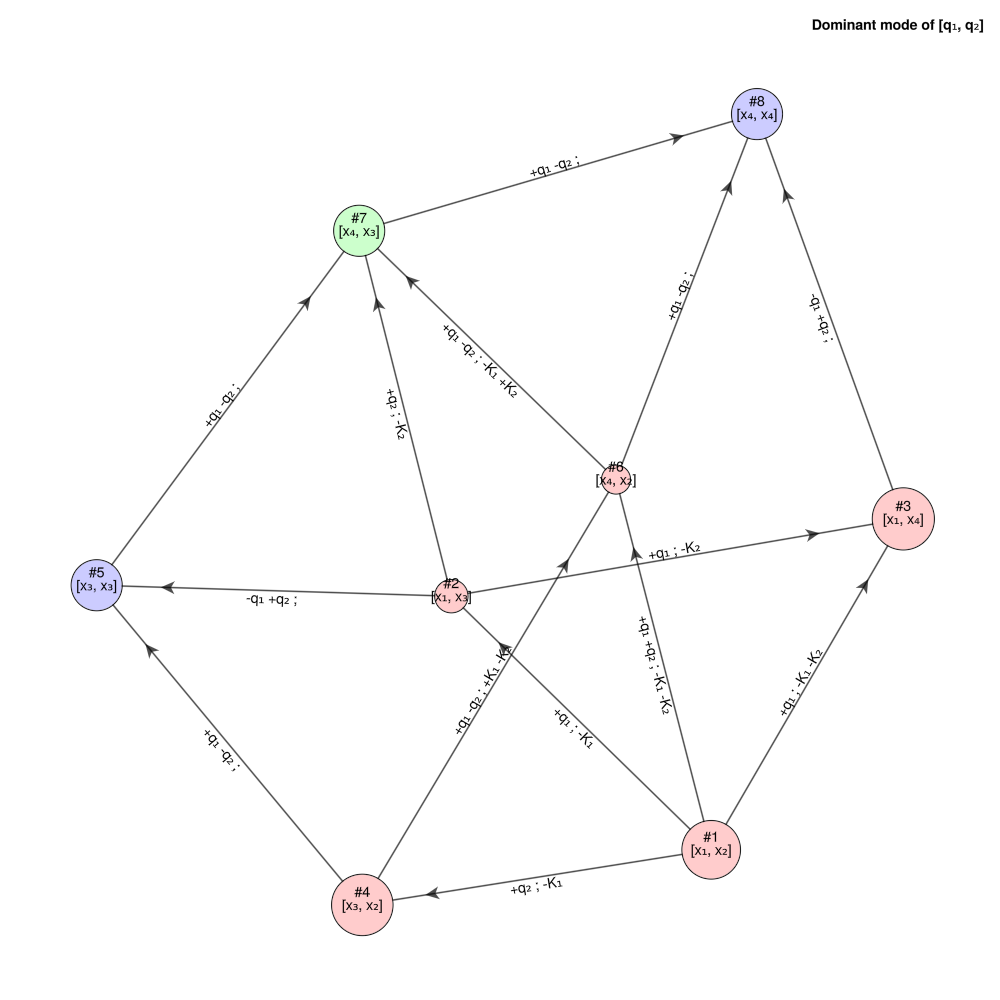

In [40]:
f,ax,p = draw_graph(model1)
f

In [139]:
p2 = SISOPaths(model2,1)

[ Info: ---------------------Start finding all vertices--------------------
[ Info: Finished, with 7 vertices found and 7 asymptotic vertices.
[ Info: -------------Start calculating nullity for each vertex, it also takes a while.------------
[ Info: 1.Building Nρ_inv cache in parallel...
[ Info: 2.Calculating nullity for each vertex in parallel...
[ Info: Start calculating vertices neighbor graph, It may takes a while.
[ Info: Calculating vertices neighbor graph with qK change dir
[ Info: sources: [4, 1]
[ Info: sinks: [3]
[ Info: Start enumerating paths from sources to sinks. This may take a while if there are many paths.
[ Info: Total vertices to process in topological order: 7
[ Info: Finished enumerating paths. Now collecting paths from sources. Total sources: 2


SISOPaths{Int8}(Bnc{Int8}([1 1 -1 0; 1 0 1 -1], [1 0 1 1; 0 1 1 1], 2, 4, 2, Symbolics.Num[x₁, x₂, x₃, x₄], Symbolics.Num[q₁, q₂], Symbolics.Num[K₁, K₂], nothing, Vector{Int8}[[1, 2], [1, 3], [1, 4], [3, 2], [3, 3], [4, 2], [4, 4]], Dict{Vector{Int8}, Int64}([4, 2] => 6, [1, 3] => 2, [3, 3] => 5, [1, 4] => 3, [1, 2] => 1, [3, 2] => 4, [4, 4] => 7), Bool[1, 1, 1, 1, 1, 1, 1], Int8[0, 0, 0, 0, 1, 0, 1], BindingAndCatalysis.VertexGraph{Int8}(Bnc{Int8}(#= circular reference @-2 =#), Graphs.SimpleGraphs.SimpleGraph{Int64}(10, [[2, 3, 4, 6], [1, 3, 5], [1, 2, 7], [1, 5, 6], [2, 4], [1, 4, 7], [3, 6]]), Vector{BindingAndCatalysis.VertexEdge{Int8}}[[BindingAndCatalysis.VertexEdge{Int8}(2, 2, sparsevec(Int8[2, 3], Int8[-1, 1], 4), -0.0, sparsevec(Int8[1, 3], [1.0, -1.0], 4), 0.0), BindingAndCatalysis.VertexEdge{Int8}(3, 2, sparsevec(Int8[2, 4], Int8[-1, 1], 4), -0.0, sparsevec(Int8[1, 3, 4], [2.0, -1.0, -1.0], 4), 0.0), BindingAndCatalysis.VertexEdge{Int8}(4, 1, sparsevec(Int8[1, 3], Int8[-1, 1

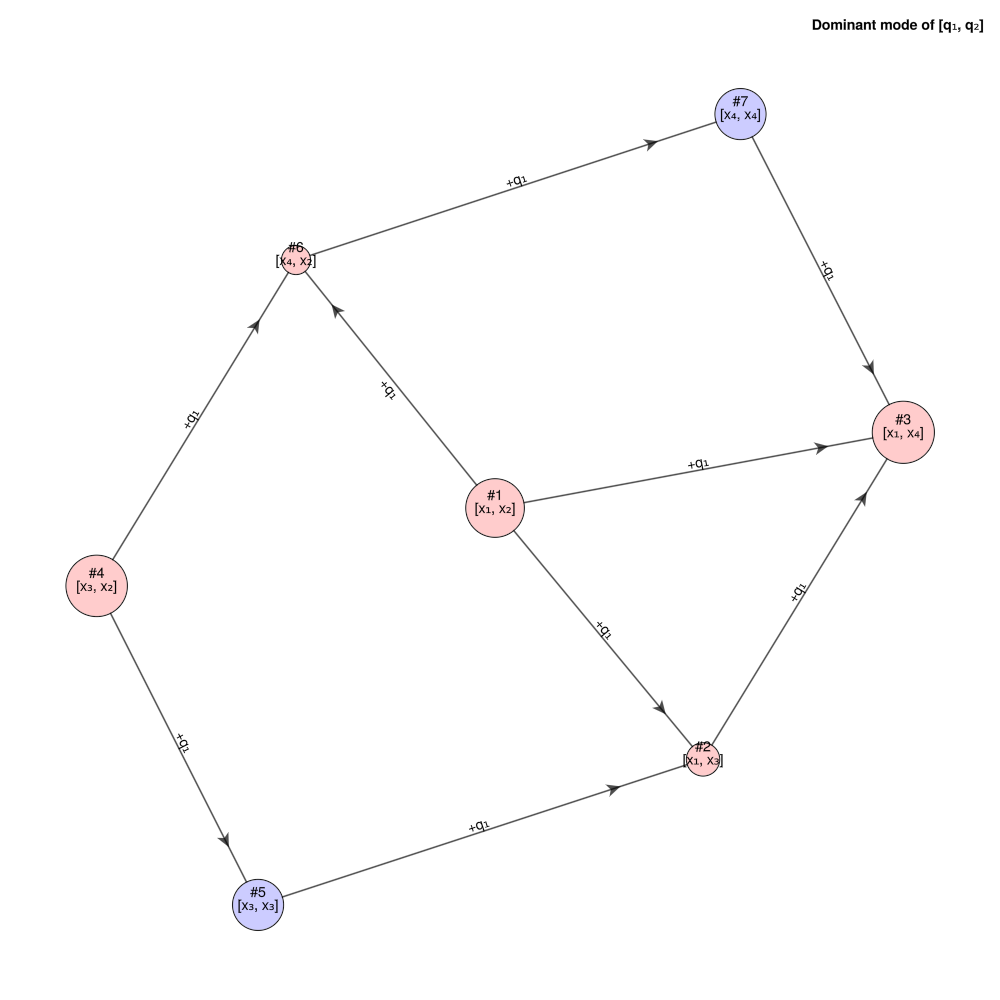

In [50]:
f,ax = draw_graph(p2); f

In [128]:
BindingAndCatalysis.N_from_L(model2.L)

2×4 Matrix{Int64}:
 1  1  -1   0
 1  1   0  -1

In [140]:
summary(p1)

[ Info: Start building polyhedra for edges (total: 12)
[ Info: Start building polyhedra for paths (total: 8)
[ Info: Number of polyhedra to calc volume: 6


Path 1         #1 → #2 → #3            Volume: 0.1658 ± 0.0008
Path 2         #1 → #3                 Volume: 0.2499 ± 0.0012
Path 3         #1 → #6 → #7 → #8 → #3  Volume: 0.0000 ± 0.0000
Path 4         #1 → #6 → #8 → #3       Volume: 0.0833 ± 0.0004
Path 5         #4 → #5 → #2 → #3       Volume: 0.1664 ± 0.0008
Path 6         #4 → #5 → #7 → #8 → #3  Volume: 0.1669 ± 0.0008
Path 7         #4 → #6 → #7 → #8 → #3  Volume: 0.0000 ± 0.0000
Path 8         #4 → #6 → #8 → #3       Volume: 0.1674 ± 0.0008


[ Info: All regimes converged after 1700000 samples.


In [141]:
summary(p2)

[ Info: Start building polyhedra for edges (total: 9)
[ Info: Start building polyhedra for paths (total: 5)


Path 1         #1 → #2 → #3       Volume: 0.1658 ± 0.0008
Path 2         #1 → #3            Volume: 0.2498 ± 0.0012
Path 3         #1 → #6 → #7 → #3  Volume: 0.0834 ± 0.0004
Path 4         #4 → #5 → #2 → #3  Volume: 0.1664 ± 0.0008
Path 5         #4 → #6 → #7 → #3  Volume: 0.1673 ± 0.0008


[ Info: Number of polyhedra to calc volume: 5
[ Info: All regimes converged after 1700000 samples.


In [59]:
show_expression_path(p1,6; log_space=false)

q₁ < q₂

4-element Vector{Symbolics.Equation}:
 x₁ ~ (K₁*q₁) / q₂
 x₂ ~ q₂
 x₃ ~ q₁
 x₄ ~ (K₁*(q₁^2.0)) / (K₂*q₂)

(q₁ > q₂) & (q₁ < q₂)

4-element Vector{Symbolics.Num}:
 ↑
 ↓
 →
 ↑

(q₁ > q₂) & (q₁ < (2.0q₂))

4-element Vector{Symbolics.Equation}:
 x₁ ~ (0.5K₂*q₁) / q₂
 x₂ ~ (2.0K₁*(q₂^2.0)) / (K₂*q₁)
 x₃ ~ q₂
 x₄ ~ 0.5q₁

(q₁ > (2.0q₂)) & (q₁ < (2.0q₂))

4-element Vector{Symbolics.Num}:
 ↑
 ↓
 ↓
 →

q₁ > (2.0q₂)

4-element Vector{Symbolics.Equation}:
 x₁ ~ q₁
 x₂ ~ (K₁*K₂*q₂) / (q₁^2.0)
 x₃ ~ (K₂*q₂) / q₁
 x₄ ~ q₂

[ Info: Change in logq₁
[ Info: parameters: Pair{Symbolics.Num, Float64}[q₂ => 3.6989700043360187, K₁ => -4.301029995663981, K₂ => 0.0]


parameters = [3.6989700043360187, -4.301029995663981, 0.0]


[ Info: Target syms contains: logx₁ 
[ Info: Target syms contains: logx₂ 
[ Info: Target syms contains: logx₃ 
[ Info: Target syms contains: logx₄ 


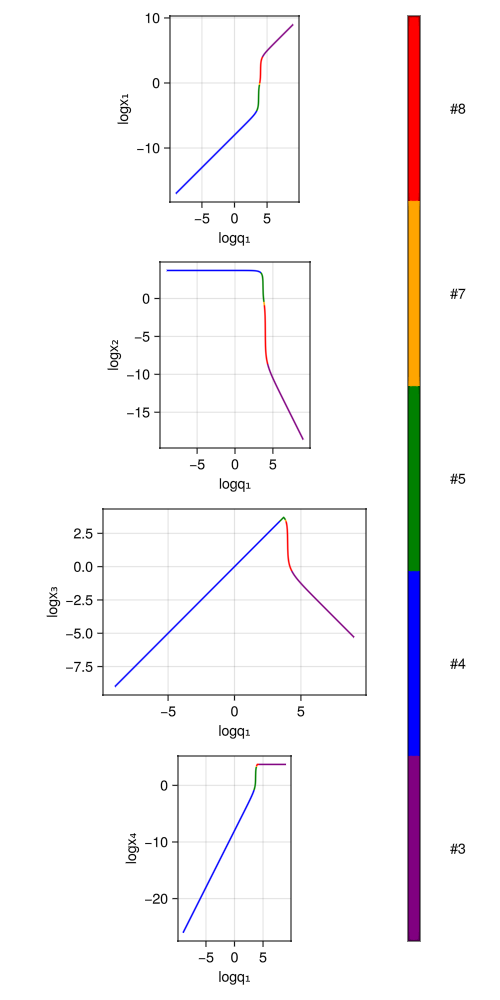

In [157]:
SISO_plot(p1,6;size = (500,1000),start = -9 ,stop = 9)

In [142]:
i =3

3

In [143]:
summary_RO_path(p1; observe_x=i,deduplicate=true,remove_redundant=true, keep_nonasymptotic=false)

Path [3, 4, 7, 8]  1 → 0.5 → -Inf → -1  Volume: 0.2507 ± 0.0009
Path [2]           1 → -1               Volume: 0.2499 ± 0.0012
Path [6]           1 → NaN → -Inf → -1  Volume: 0.1669 ± 0.0008
Path [5]           1 → NaN → 0 → -1     Volume: 0.1664 ± 0.0008
Path [1]           1 → 0 → -1           Volume: 0.1658 ± 0.0008


In [144]:
summary_RO_path(p2; observe_x=i,deduplicate=true,remove_redundant=true, keep_nonasymptotic=false)

Path [3, 5]    1 → 0.5 → -Inf → -1  Volume: 0.2507 ± 0.0009
Path [2]       1 → -1               Volume: 0.2498 ± 0.0012
Path [4]       1 → NaN → 0 → -1     Volume: 0.1664 ± 0.0008
Path [1]       1 → 0 → -1           Volume: 0.1658 ± 0.0008


In [106]:
get_path(p1,6)

5-element Vector{Vector{Int8}}:
 [3, 2]
 [3, 3]
 [4, 3]
 [4, 4]
 [1, 4]

In [108]:
show_condition(p1,6; log_space=false)

2-element Vector{Symbolics.Num}:
 (0.5K₂) > K₁
 (2.0q₂) > K₂

So we should keep the L value that not equals 1, as that will make us skip some behavior as the Path #6, 

when the dominance mode shift #4,#5,#7,#8,#3

or we use the perm: $[3,2], [3,3], [4,3],[4,4],[1,4]$

And $[4,3]$ is that non-asymptotic regime, 

This path have condition: $K2 > 2K1$ and $2q2 > K2$, with volume $0.1672$

With unique behavior for x3 and x4, even if we skip regime $[4,3]$,\\
For x3, that unique behavior is : 1 → NaN → -Inf → -1, \\
For x4, that unique behavior is : 2 → -Inf → 0\\



In [112]:
show_conservation(model1)

2-element Vector{Symbolics.Equation}:
 q₁ ~ x₁ + x₃ + 2x₄
 q₂ ~ x₂ + x₃ + x₄

emph_rays_direct = Tuple{Point{2, Float32}, Point{2, Float32}}[]


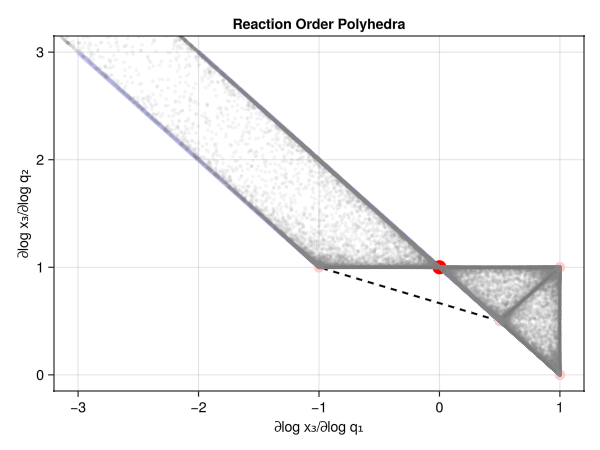

In [127]:
f,ax = draw_ROP(model1, [(:x₃, :q₁), (:x₃, :q₂)]; emphasize_regimes=[[4,3]],npoints=100000)
f

emph_rays_direct = Tuple{Point{2, Float32}, Point{2, Float32}}[]


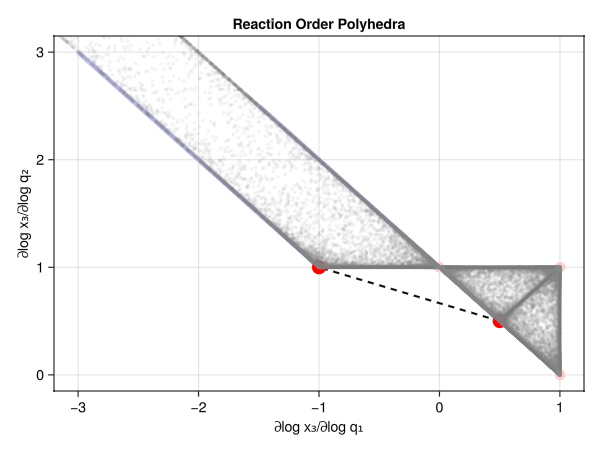

In [126]:
f,ax = draw_ROP(model2, [(:x₃, :q₁), (:x₃, :q₂)]; emphasize_regimes=[3,6],npoints=100000)
f

In [130]:
model3 = Bnc(L = model2.L)

----------Binding Network Summary:-------------
Number of species (n): 4
Number of conserved quantities (d): 2
Number of reactions (r): 2
L matrix: [1 0 1 1; 0 1 1 1]
N matrix: [1 1 -1 0; 1 1 0 -1]
Direction of binding reactions: forward
Catalysis involved: No
Regimes constructed: No
-----------------------------------------------

[ Info: ---------------------Start finding all vertices--------------------
[ Info: Finished, with 7 vertices found and 7 asymptotic vertices.
[ Info: -------------Start calculating nullity for each vertex, it also takes a while.------------
[ Info: 1.Building Nρ_inv cache in parallel...
[ Info: 2.Calculating nullity for each vertex in parallel...
[ Info: Start calculating vertices neighbor graph, It may takes a while.
[ Info: Calculating vertices neighbor graph with qK change dir
[ Info: Number of polyhedra to calc volume: 5
[ Info: All regimes converged after 800000 samples.


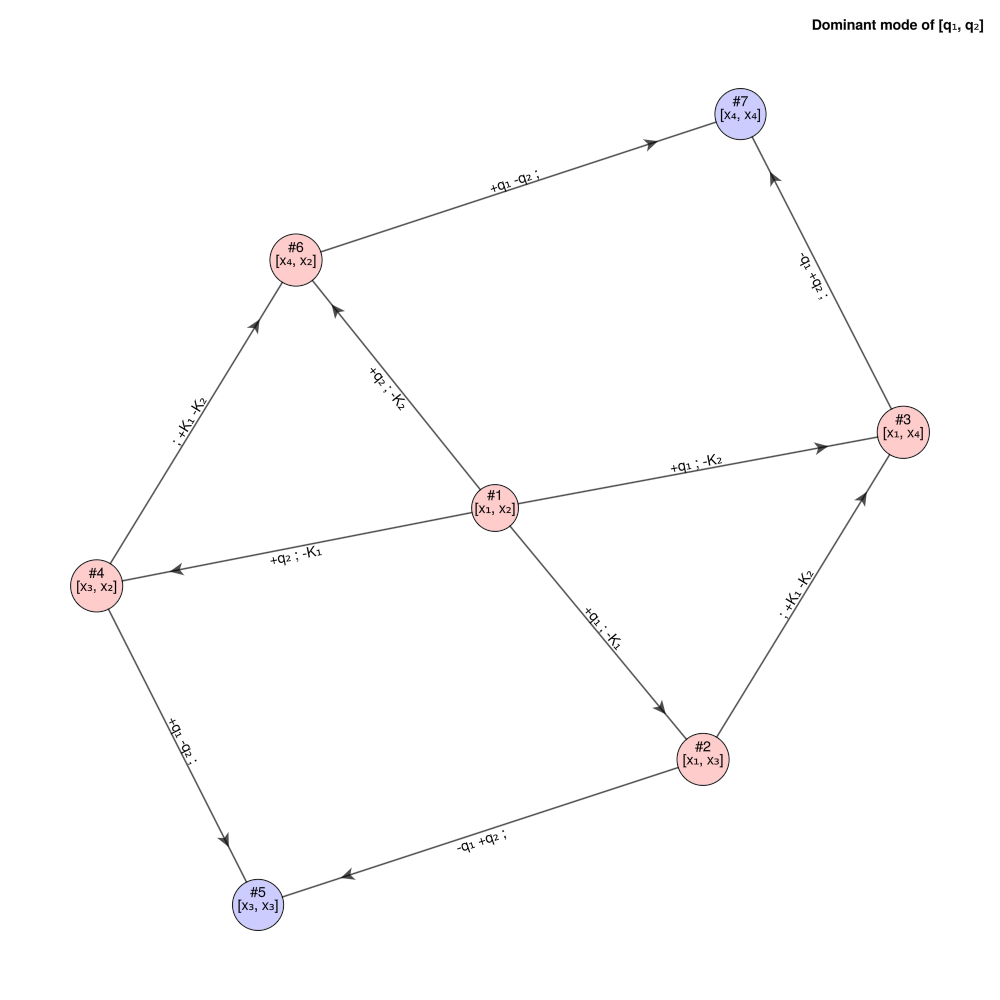

In [131]:
f,x = draw_graph(model3)
f

In [132]:
p3 = SISOPaths(model3,1)

[ Info: sources: [4, 6, 1]
[ Info: sinks: [2, 3]
[ Info: Start enumerating paths from sources to sinks. This may take a while if there are many paths.
[ Info: Total vertices to process in topological order: 7
[ Info: Finished enumerating paths. Now collecting paths from sources. Total sources: 3


SISOPaths{Int8}(Bnc{Int8}([1 1 -1 0; 1 1 0 -1], [1 0 1 1; 0 1 1 1], 2, 4, 2, Symbolics.Num[x₁, x₂, x₃, x₄], Symbolics.Num[q₁, q₂], Symbolics.Num[K₁, K₂], nothing, Vector{Int8}[[1, 2], [1, 3], [1, 4], [3, 2], [3, 3], [4, 2], [4, 4]], Dict{Vector{Int8}, Int64}([4, 2] => 6, [1, 3] => 2, [3, 3] => 5, [1, 4] => 3, [1, 2] => 1, [3, 2] => 4, [4, 4] => 7), Bool[1, 1, 1, 1, 1, 1, 1], Int8[0, 0, 0, 0, 1, 0, 1], BindingAndCatalysis.VertexGraph{Int8}(Bnc{Int8}(#= circular reference @-2 =#), Graphs.SimpleGraphs.SimpleGraph{Int64}(10, [[2, 3, 4, 6], [1, 3, 5], [1, 2, 7], [1, 5, 6], [2, 4], [1, 4, 7], [3, 6]]), Vector{BindingAndCatalysis.VertexEdge{Int8}}[[BindingAndCatalysis.VertexEdge{Int8}(2, 2, sparsevec(Int8[2, 3], Int8[-1, 1], 4), -0.0, sparsevec(Int8[1, 3], [1.0, -1.0], 4), 0.0), BindingAndCatalysis.VertexEdge{Int8}(3, 2, sparsevec(Int8[2, 4], Int8[-1, 1], 4), -0.0, sparsevec(Int8[1, 4], [1.0, -1.0], 4), 0.0), BindingAndCatalysis.VertexEdge{Int8}(4, 1, sparsevec(Int8[1, 3], Int8[-1, 1], 4), -0

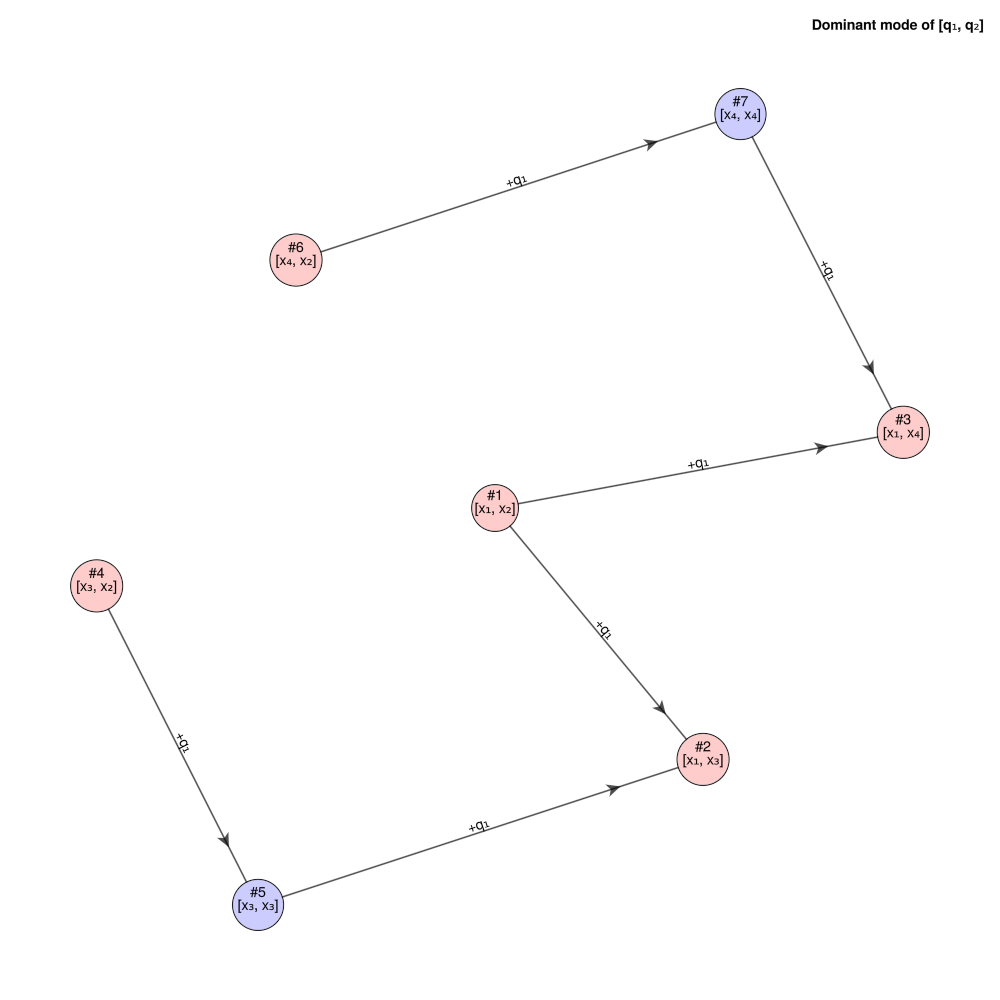

In [134]:
f,ax = draw_graph(p3); f